In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
COLLECTING DATA FROM API

                       Date       Open       High        Low      Close  \
0 2024-06-20 00:00:00-04:00  10.857415  11.098486  10.801784  11.070669   
1 2024-06-21 00:00:00-04:00  11.033581  11.042853  10.903775  10.977950   
2 2024-06-24 00:00:00-04:00  11.061397  11.358098  11.052125  11.339554   
3 2024-06-25 00:00:00-04:00  11.283924  11.321012  11.154117  11.209749   
4 2024-06-26 00:00:00-04:00  11.135574  11.246837  11.079942  11.228292   

     Volume  Dividends  Stock Splits  
0  53468000        0.0           0.0  
1  50201900        0.0           0.0  
2  58436900        0.0           0.0  
3  39323900        0.0           0.0  
4  41426600        0.0           0.0  


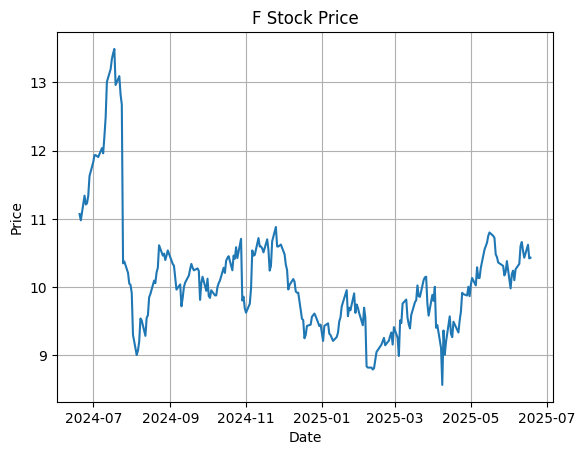

In [3]:
symbol = "F"
df = yf.Ticker(symbol).history(period='1y').reset_index()
print(df.head())
sns.lineplot(data=df, x='Date', y='Close')
plt.title(f'{symbol} Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()
df.to_csv("data.csv", index=False)

In [ ]:
EXPLORATORY CHECKING

In [4]:
df.info()
print("\n--- Basic descriptive statistics of numerical data ---")
df.describe()
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)
print(f"\n--- Number of duplicate rows: {df.duplicated().sum()} ---")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          250 non-null    datetime64[ns, America/New_York]
 1   Open          250 non-null    float64                         
 2   High          250 non-null    float64                         
 3   Low           250 non-null    float64                         
 4   Close         250 non-null    float64                         
 5   Volume        250 non-null    int64                           
 6   Dividends     250 non-null    float64                         
 7   Stock Splits  250 non-null    float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 15.8 KB

--- Basic descriptive statistics of numerical data ---
Date            0
Open            0
High            0
Low             0


In [ ]:
DATA PREPROCESSING

In [5]:
df['Date']=pd.to_datetime(df['Date'], utc=True)

In [ ]:
CALCULATING FUNDAMENTAL TECHNICAL INDICATORS

In [6]:
df = pd.read_csv("data.csv", parse_dates=['Date'])

In [7]:
#SMA: Simple Moving Average
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [8]:
#EMA: Exponential Moving Average
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

In [18]:
#RSI: Relative Strength Index
df['RSI_14'] = 100 - (100 / (1 + df['Close'].diff().apply(lambda x: x if x > 0 else 0).rolling(14).mean() / df['Close'].diff().apply(lambda x: -x if x < 0 else 0).rolling(14).mean()))

In [ ]:
DATA ANALYSIS

In [9]:
df['Daily_return'] = df['Close'].pct_change() * 100

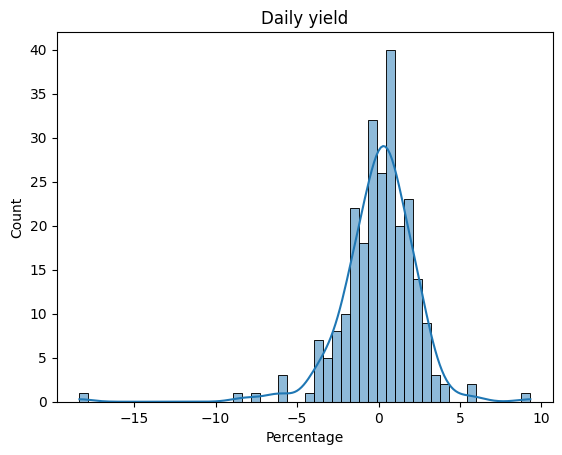

In [10]:
sns.histplot(df['Daily_return'].dropna(), bins=50, kde=True)
plt.title("Daily yield")
plt.xlabel("Percentage")
plt.show()

In [13]:
df['Date']=pd.to_datetime(df['Date'], utc=True)
df['Date'] = df['Date'].dt.tz_localize(None)
df['Month'] = df['Date'].dt.to_period('M')
monthly_volatility = df.groupby('Month')['Daily_return'].std()

In [14]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].dt.tz_localize(None)
df['Quarter'] = df['Date'].dt.to_period('Q')
quarterly_volatility = df.groupby('Quarter')['Daily_return'].std()

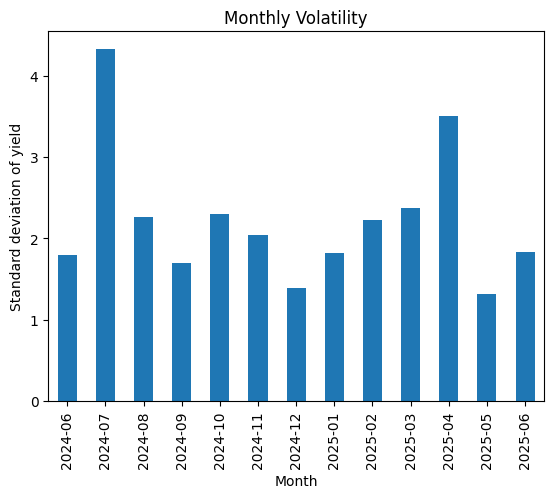

In [15]:
monthly_volatility.plot(kind='bar', title='Monthly Volatility')
plt.ylabel('Standard deviation of yield')
plt.show()

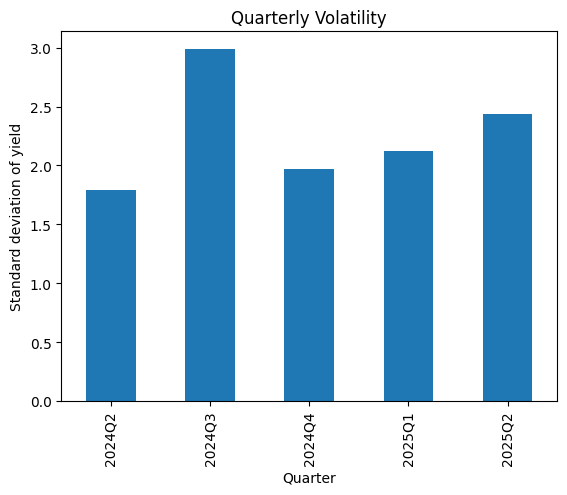

In [16]:
quarterly_volatility.plot(kind='bar', title='Quarterly Volatility')
plt.ylabel('Standard deviation of yield')
plt.show()

           Close    SMA_20    RSI_14
Close   1.000000  0.555058  0.627833
SMA_20  0.555058  1.000000 -0.240932
RSI_14  0.627833 -0.240932  1.000000


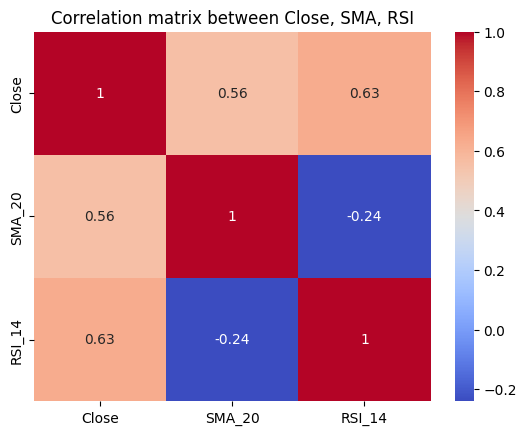

In [19]:
corr = df[['Close', 'SMA_20', 'RSI_14']].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix between Close, SMA, RSI')
plt.show()

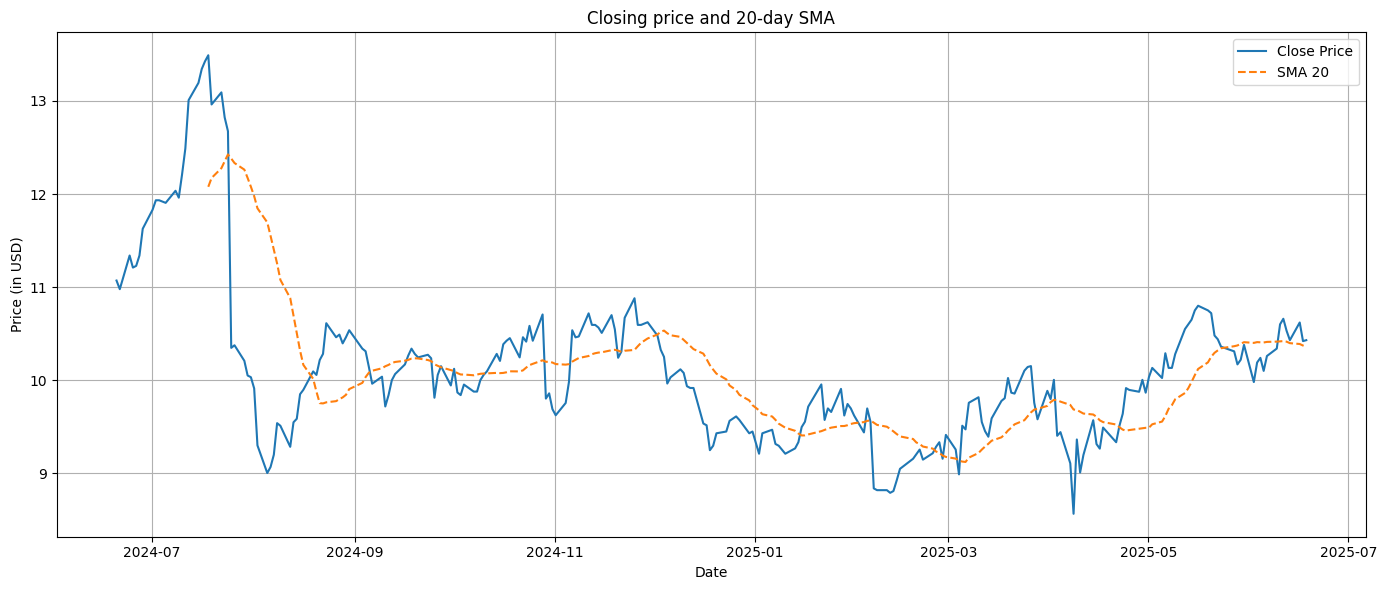

In [20]:
#Correlation chart between SMA and Price
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20', linestyle='--')
plt.title('Closing price and 20-day SMA')
plt.xlabel('Date')
plt.ylabel('Price (in USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
#Linear Regression between SMA and Closing Price
import statsmodels.api as sm 
reg_df = df.dropna(subset=['Close', 'SMA_20'])   
X = reg_df[['SMA_20']]
y = reg_df['Close']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     102.0
Date:                Fri, 20 Jun 2025   Prob (F-statistic):           4.56e-20
Time:                        14:41:28   Log-Likelihood:                -192.22
No. Observations:                 231   AIC:                             388.4
Df Residuals:                     229   BIC:                             395.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3893      0.554      7.918      0.0

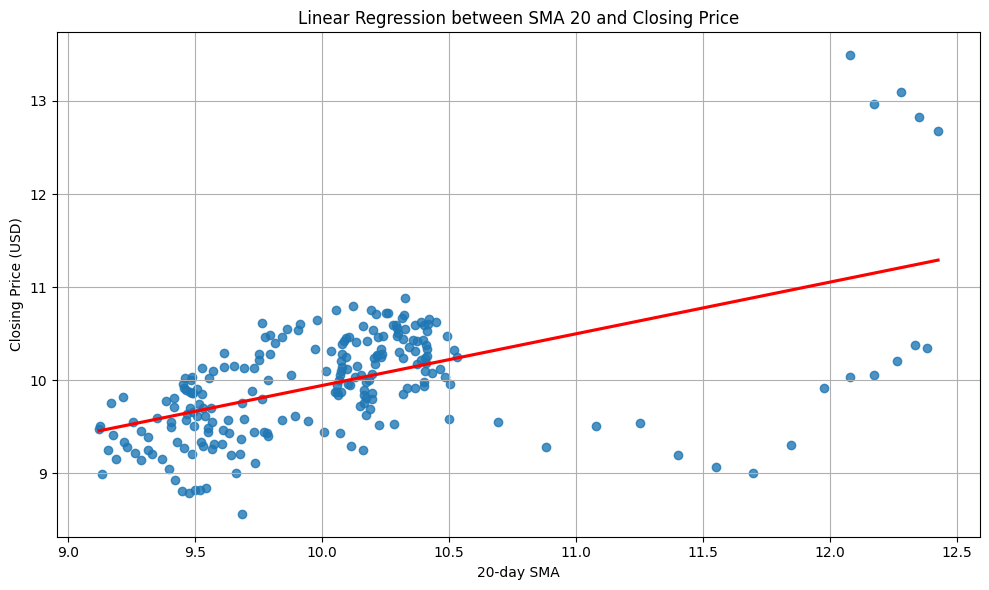

In [44]:
plt.figure(figsize=(10, 6))
sns.regplot(data=reg_df, x='SMA_20', y='Close', ci=None, line_kws={'color': 'red'})
plt.title('Linear Regression between SMA 20 and Closing Price')
plt.xlabel('20-day SMA')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
DATA VISUALIZATION

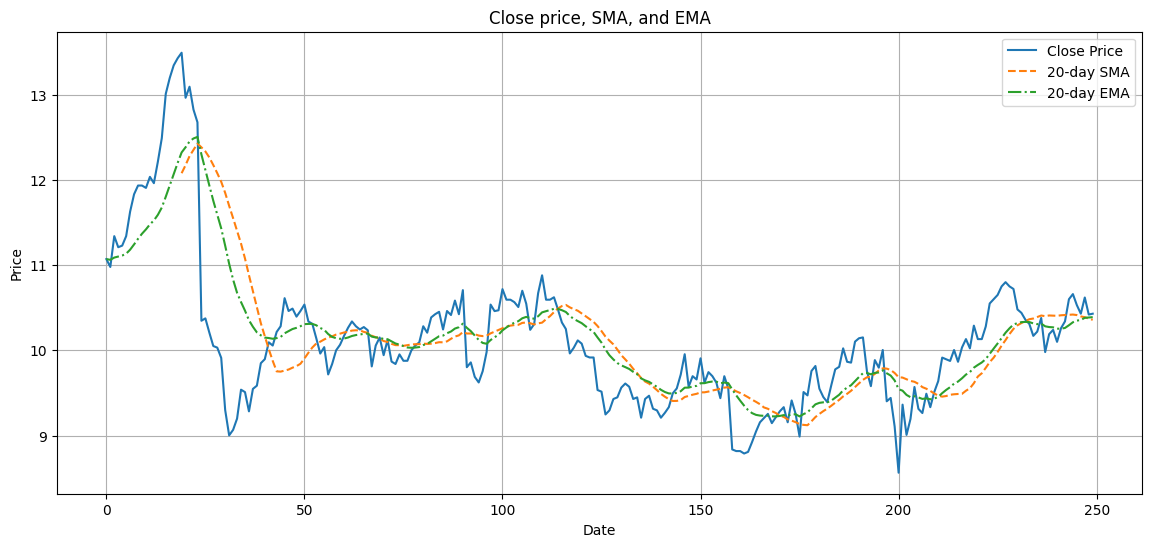

In [45]:
#Close Price, SMA, and EMA
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='20-day SMA', linestyle='--')
plt.plot(df['EMA_20'], label='20-day EMA', linestyle='-.')
plt.title('Close price, SMA, and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

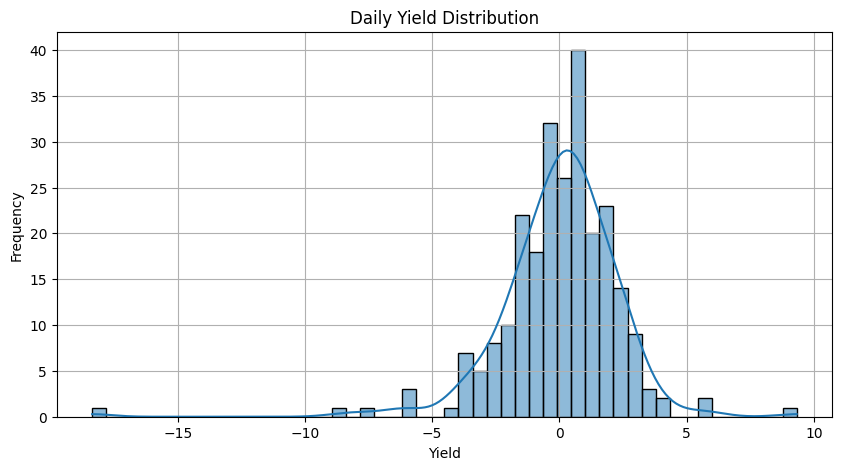

In [46]:
#Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_return'].dropna(), bins=50, kde=True)
plt.title('Daily Yield Distribution')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

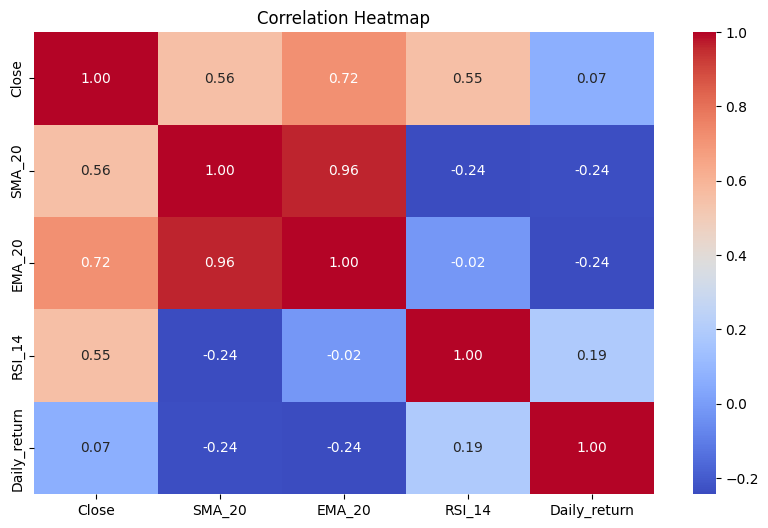

In [47]:
#Correlation Heatmap between variables
corr_df = df[['Close', 'SMA_20', 'EMA_20', 'RSI_14', 'Daily_return']].dropna()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()